In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file_path = r"D:\Data-Analysis-Portfolio\datasets\Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [10]:
df["SalesAmount"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [11]:
total_sales = df["SalesAmount"].sum()

total_sales

np.float64(9747747.933999998)

In [12]:
df.duplicated().sum()

np.int64(5268)

In [13]:
df_clean = df.drop_duplicates()

df_clean.shape

(536641, 9)

In [14]:
df_clean = df_clean.dropna(subset=["CustomerID"])

df_clean.shape

(401604, 9)

In [15]:
df_clean = df_clean.dropna(subset=["Description"])

df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
SalesAmount    0
dtype: int64

In [16]:
df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")].shape

(8872, 9)

In [17]:
df_clean[df_clean["Quantity"] <= 0].shape

(8872, 9)

In [18]:
df_clean = df_clean[~df_clean["InvoiceNo"].astype(str).str.startswith("C")]

df_clean = df_clean[df_clean["Quantity"] > 0]

df_clean = df_clean[df_clean["UnitPrice"] > 0]

df_clean.shape

(392692, 9)

In [19]:
df_clean["SalesAmount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [20]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   SalesAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [21]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,SalesAmount
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892480,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [22]:
output_path = r"D:\Data-Analysis-Portfolio\01_Ecommerce_Analysis\output\online_retail_clean.xlsx"

df_clean.to_excel(output_path, index=False)

print("清洗后的数据已保存：", output_path)

清洗后的数据已保存： D:\Data-Analysis-Portfolio\01_Ecommerce_Analysis\output\online_retail_clean.xlsx


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

clean_path = r"D:\Data-Analysis-Portfolio\01_Ecommerce_Analysis\output\online_retail_clean.xlsx"

df_clean = pd.read_excel(clean_path)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [24]:
df_clean.shape

(392692, 9)

In [25]:
print("总销售额：", round(total_sales, 2))

总销售额： 9747747.93


In [26]:
total_orders = df_clean["InvoiceNo"].nunique()

print("总订单数：", total_orders)

总订单数： 18532


In [27]:
total_customers = df_clean["CustomerID"].nunique()

print("总客户数：", total_customers)

总客户数： 4338


In [28]:
avg_order_value = total_sales / total_orders

print("客单价：", round(avg_order_value, 2))

客单价： 526.0


In [29]:
summary = pd.DataFrame({
    "指标": ["总销售额", "总订单数", "总客户数", "客单价"],
    "数值": [
        round(total_sales, 2),
        total_orders,
        total_customers,
        round(avg_order_value, 2)
    ]
})

summary

,指标,数值
0,总销售额,9747747.93
1,总订单数,18532.00
2,总客户数,4338.00
3,客单价,526.00


In [30]:
top_quantity_products = df_clean.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

top_quantity_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [31]:
top_sales_products = df_clean.groupby("Description")["SalesAmount"].sum().sort_values(ascending=False).head(10)

top_sales_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: SalesAmount, dtype: float64

In [32]:
top_countries = df_clean.groupby("Country")["SalesAmount"].sum().sort_values(ascending=False).head(10)

top_countries

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: SalesAmount, dtype: float64

In [33]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)

df_clean[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [34]:
monthly_sales = df_clean.groupby("Month")["SalesAmount"].sum().reset_index()

monthly_sales

,Month,SalesAmount
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331
5,2011-05,677355.150
6,2011-06,660046.050
7,2011-07,598962.901
8,2011-08,644051.040
9,2011-09,950690.202


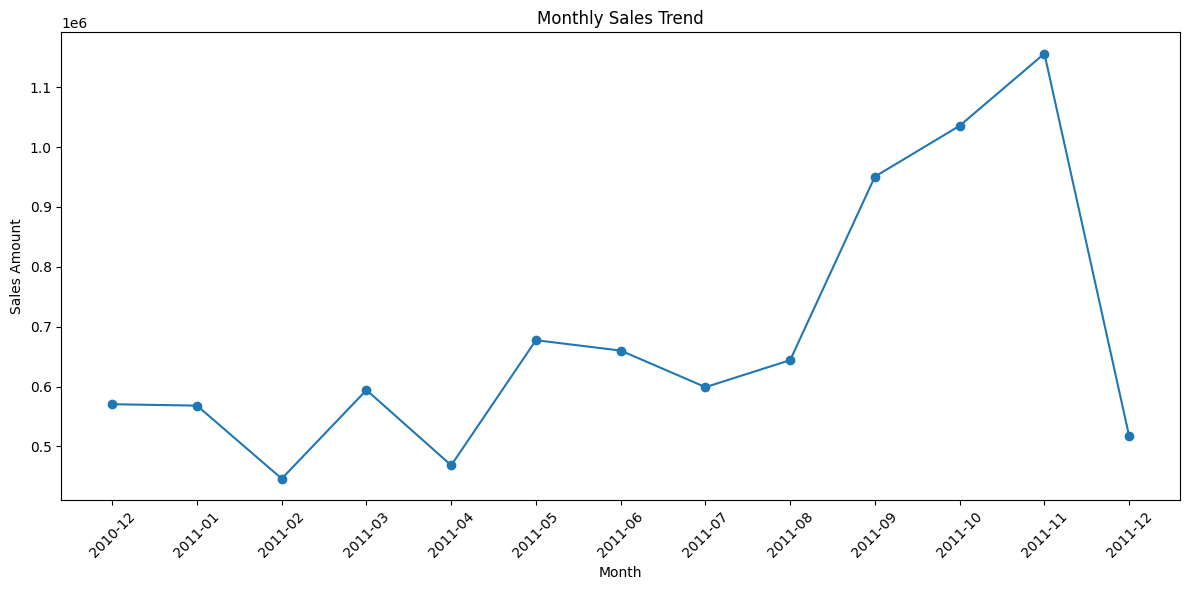

In [35]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["Month"], monthly_sales["SalesAmount"], marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.tight_layout()
plt.show()

In [36]:
df_clean["InvoiceDate"].max()

Timestamp('2011-12-09 12:50:00')

In [37]:
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

analysis_date

Timestamp('2011-12-10 12:50:00')

In [38]:
rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (analysis_date - x.max()).days,
    "InvoiceNo": "nunique",
    "SalesAmount": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [39]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


In [40]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5])

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346,326,1,77183.60,1,1,5
1,12347,2,7,4310.00,5,5,5
2,12348,75,4,1797.24,2,4,4
3,12349,19,1,1757.55,4,1,4
4,12350,310,1,334.40,1,1,2


In [41]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


In [42]:
def segment_customer(row):
    R = int(row["R_score"])
    F = int(row["F_score"])
    M = int(row["M_score"])
    
    if R >= 4 and F >= 4 and M >= 4:
        return "高价值用户"
    elif R >= 4 and F >= 3:
        return "重点发展用户"
    elif R <= 2 and F >= 4 and M >= 4:
        return "重点唤回用户"
    elif R <= 2 and F <= 2:
        return "流失风险用户"
    else:
        return "一般用户"

rfm["UserSegment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,UserSegment
0,12346,326,1,77183.60,1,1,5,115,流失风险用户
1,12347,2,7,4310.00,5,5,5,555,高价值用户
2,12348,75,4,1797.24,2,4,4,244,重点唤回用户
3,12349,19,1,1757.55,4,1,4,414,一般用户
4,12350,310,1,334.40,1,1,2,112,流失风险用户


In [43]:
segment_count = rfm["UserSegment"].value_counts()

segment_count

UserSegment
一般用户      1652
流失风险用户    1065
高价值用户      957
重点发展用户     496
重点唤回用户     168
Name: count, dtype: int64

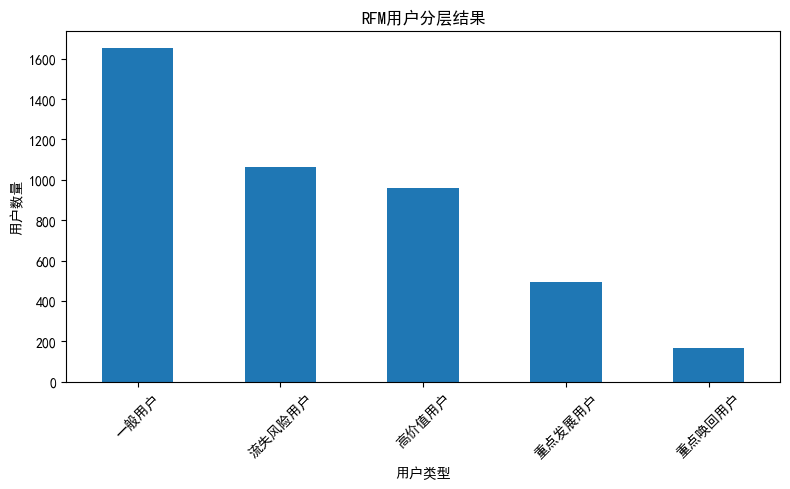

In [46]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 5))
segment_count.plot(kind="bar")
plt.title("RFM用户分层结果")
plt.xlabel("用户类型")
plt.ylabel("用户数量")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
rfm_output_path = r"D:\Data-Analysis-Portfolio\01_Ecommerce_Analysis\output\rfm_customer_segment.xlsx"

rfm.to_excel(rfm_output_path, index=False)

print("RFM用户分层结果已保存：", rfm_output_path)

RFM用户分层结果已保存： D:\Data-Analysis-Portfolio\01_Ecommerce_Analysis\output\rfm_customer_segment.xlsx


In [47]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,UserSegment
0,12346,326,1,77183.60,1,1,5,115,流失风险用户
1,12347,2,7,4310.00,5,5,5,555,高价值用户
2,12348,75,4,1797.24,2,4,4,244,重点唤回用户
3,12349,19,1,1757.55,4,1,4,414,一般用户
4,12350,310,1,334.40,1,1,2,112,流失风险用户


In [48]:
segment_summary = rfm["UserSegment"].value_counts().reset_index()

segment_summary.columns = ["用户类型", "用户数量"]

segment_summary["占比"] = segment_summary["用户数量"] / segment_summary["用户数量"].sum()

segment_summary["占比"] = segment_summary["占比"].apply(lambda x: f"{x:.2%}")

segment_summary

,用户类型,用户数量,占比
0,一般用户,1652,38.08%
1,流失风险用户,1065,24.55%
2,高价值用户,957,22.06%
3,重点发展用户,496,11.43%
4,重点唤回用户,168,3.87%


In [49]:
segment_analysis = rfm.groupby("UserSegment").agg({
    "CustomerID": "count",
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).reset_index()

segment_analysis.columns = ["用户类型", "用户数量", "平均最近消费间隔", "平均购买次数", "平均消费金额"]

segment_analysis

,用户类型,用户数量,平均最近消费间隔,平均购买次数,平均消费金额
0,一般用户,1652,77.469128,2.615617,1012.239880
1,流失风险用户,1065,217.897653,1.101408,486.687467
2,重点发展用户,496,16.161290,2.951613,1077.675143
3,重点唤回用户,168,125.559524,5.529762,2205.350298
4,高价值用户,957,12.824451,11.123302,6051.871202


In [50]:
segment_analysis["平均最近消费间隔"] = segment_analysis["平均最近消费间隔"].round(2)
segment_analysis["平均购买次数"] = segment_analysis["平均购买次数"].round(2)
segment_analysis["平均消费金额"] = segment_analysis["平均消费金额"].round(2)

segment_analysis

,用户类型,用户数量,平均最近消费间隔,平均购买次数,平均消费金额
0,一般用户,1652,77.47,2.62,1012.24
1,流失风险用户,1065,217.90,1.10,486.69
2,重点发展用户,496,16.16,2.95,1077.68
3,重点唤回用户,168,125.56,5.53,2205.35
4,高价值用户,957,12.82,11.12,6051.87


In [51]:
strategy_dict = {
    "高价值用户": "重点维护，提供会员权益、专属折扣、新品优先推荐，提升用户忠诚度。",
    "重点发展用户": "近期活跃但消费潜力未完全释放，可通过满减活动、组合推荐、积分奖励提升消费频次和金额。",
    "重点唤回用户": "历史消费能力较强但近期活跃度下降，可通过专属优惠券、短信提醒、限时活动进行召回。",
    "流失风险用户": "近期消费间隔较长且消费频率较低，应通过低门槛优惠券、老客回归活动提升回流率。",
    "一般用户": "保持基础运营，通过个性化推荐、促销活动和会员积分机制逐步提升用户价值。"
}

segment_analysis["运营策略"] = segment_analysis["用户类型"].map(strategy_dict)

segment_analysis

,用户类型,用户数量,平均最近消费间隔,平均购买次数,平均消费金额,运营策略
0,一般用户,1652,77.47,2.62,1012.24,保持基础运营，通过个性化推荐、促销活动和会员积分机制逐步提升用户价值。
1,流失风险用户,1065,217.90,1.10,486.69,近期消费间隔较长且消费频率较低，应通过低门槛优惠券、老客回归活动提升回流率。
2,重点发展用户,496,16.16,2.95,1077.68,近期活跃但消费潜力未完全释放，可通过满减活动、组合推荐、积分奖励提升消费频次和金额。
3,重点唤回用户,168,125.56,5.53,2205.35,历史消费能力较强但近期活跃度下降，可通过专属优惠券、短信提醒、限时活动进行召回。
4,高价值用户,957,12.82,11.12,6051.87,重点维护，提供会员权益、专属折扣、新品优先推荐，提升用户忠诚度。


In [52]:
strategy_output_path = r"D:\Data-Analysis-Portfolio\01_Ecommerce_Analysis\output\rfm_user_strategy.xlsx"

segment_analysis.to_excel(strategy_output_path, index=False)

print("用户运营策略分析结果已保存：", strategy_output_path)

用户运营策略分析结果已保存： D:\Data-Analysis-Portfolio\01_Ecommerce_Analysis\output\rfm_user_strategy.xlsx


## RFM用户分层分析结论

本项目基于清洗后的39万+条有效电商交易数据，构建RFM用户价值分层模型，从最近消费时间、购买频率和消费金额三个维度对用户进行分类。

分析结果显示，平台用户主要分为高价值用户、重点发展用户、重点唤回用户、流失风险用户和一般用户。其中，一般用户数量最多，说明平台用户结构以中低活跃用户为主；高价值用户具有较高的购买频率和消费金额，是平台重点维护对象；流失风险用户数量较多，需要通过优惠券、短信召回和老客专属活动提升回流率。

基于分析结果，建议平台针对不同用户群体采取差异化运营策略：对高价值用户进行会员权益维护，对重点发展用户进行复购引导，对重点唤回用户进行精准召回，对流失风险用户开展低门槛促销活动。